In [1]:
# Calculating mortality for the year 2000 to see if it matches GBD 21

In [2]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# === Attributal fraction ===
def att_frac(x, TMREL, beta):
    # equation is: AF = (RR - 1)/RR
    # where RR = e^(beta*(x-TMREL))
    # Akritidis et al. (2024) - unsure which reference would be best

    O3_diff = x - TMREL
    TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)  # where the difference < 0 set to 0

    RR = np.exp(beta * TMREL_O3)
    AF = (RR - 1)/RR
    return AF


# === Mortality equation ===
def mortality(AF, bmr, pop):
    # equation is: M(x,y) = AF(x,y) * BMR_c * POP(x,y)
    # Akritidis et al. (2024) - unsure which reference would be best
    M = AF * bmr * pop
    return M


# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)

In [4]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"

In [5]:
# === Load data ===
bmr = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_COPD_1990-2009.nc")
pop_2000 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000.nc")
o3_2000 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"].sel(year=slice("1990", "2009")).mean("year")

In [6]:
pop_lat = pop_2000.lat.values
pop_lon = pop_2000.lon.values

o3_lat = o3_2000.latitude.values
o3_lon = o3_2000.longitude.values

bmr_lat = bmr.lat.values
bmr_lon = bmr.lon.values

In [7]:
# O3 and bmr have slightly different lat/lon limits so here we want to select the same limits as the population data
o3_lat_mask = xr.ufuncs.logical_and(o3_lat <= pop_lat.max(), o3_lat >= pop_lat.min())
o3_lon_mask = xr.ufuncs.logical_and(o3_lon <= pop_lon.max(), o3_lon >= pop_lon.min())

bmr_lat_mask = xr.ufuncs.logical_and(bmr_lat <= pop_lat.max(), bmr_lat >= pop_lat.min())
bmr_lon_mask = xr.ufuncs.logical_and(bmr_lon <= pop_lon.max(), bmr_lon >= pop_lon.min())

In [10]:
# Match dimensions to population exactly
new_o3 = o3_2000.sel(latitude=o3_lat_mask)  # longitudes are the same
new_bmr = bmr.sel(lat=bmr_lat_mask)  # longitudes are the same

o3_interp = new_o3.interp(latitude=pop_2000.lat, longitude=pop_2000.lon, method="linear")
bmr_interp = new_bmr.interp(lat=pop_2000.lat, lon=pop_2000.lon, method="linear")

In [11]:
# Calculate beta from RR GBD21 data
RR_10ppb = 1.074  # From GBD21, relative risk for 10ppb increase in OSDMA8
# RR = np.exp(beta*(x-TMREL)); x = o3
beta = np.log(RR_10ppb)/10
TMREL = 32.4  # From GBD21, update to include lower and upper bounds too

In [13]:
AF = att_frac(o3_interp, TMREL, beta)
M = mortality(AF, bmr_interp, pop_2000)

In [14]:
weighted_sum(M)

<xarray.DataArray (quantile: 3)> Size: 24B
array([214090.27726092, 245643.66737954, 274199.39542525])
Coordinates:
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'

In [15]:
# Calculate country specific mortality using country masks
masks = xr.open_dataarray(f"{BMR_DIR}GBD_Country_Masks_0.10_newlabels.nc")

In [16]:
masks_lat_mask = xr.ufuncs.logical_and(masks.lat.values <= pop_lat.max(), masks.lat.values >= pop_lat.min())
new_masks = masks.sel(lat=masks_lat_mask)
masks_interp = new_masks.interp(lat=pop_2000.lat, lon=pop_2000.lon, method="linear")

In [17]:
# Create DataArray filled with NaNs
global_M_array = xr.DataArray(
    np.full((len(M.lat), len(M.lon)), np.nan),
    coords={"lat": M.lat.values, "lon": M.lon.values},
    dims=["lat", "lon"]
)

In [18]:
# Loop over countries, add the population for each country and apply using country mask
for i in range(204):
    mask = masks_interp.isel(country=i)
    country = masks_interp.isel(country=i)["country"]
    M_country = weighted_sum(xr.where(masks_interp.isel(country=i) == 1, M.sel(quantile="median"), np.nan)) # mortality of country
    global_M_array = global_M_array.where(mask == 0, M_country)

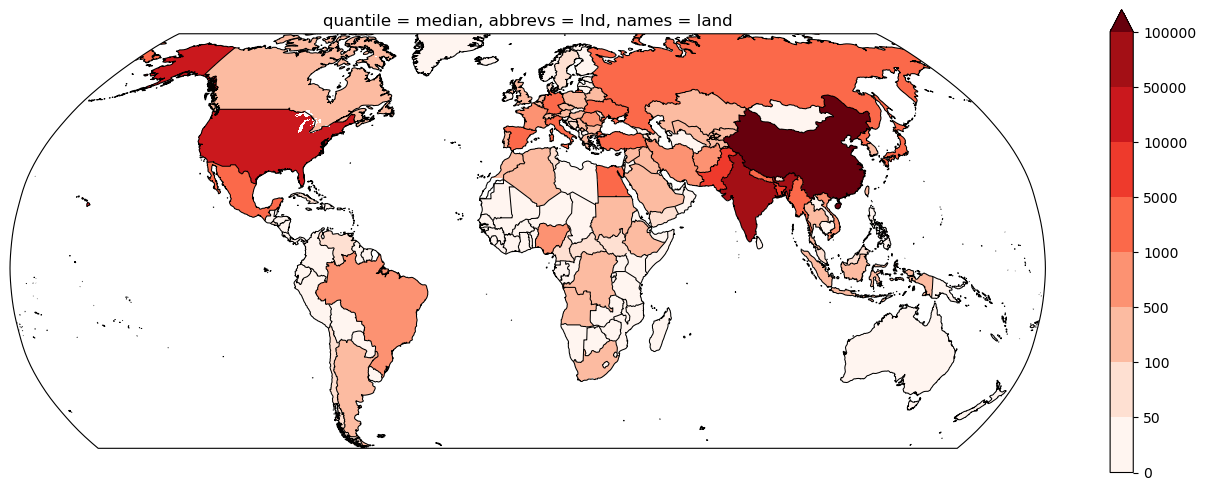

In [19]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(global_M_array).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
#regionmask.defined_regions.natural_earth_v5_0_0.countries_110.plot(add_label=False)


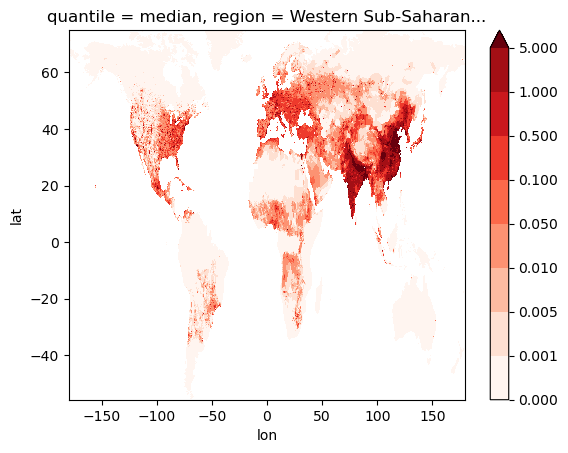

In [22]:
M.sel(quantile="median").plot(cmap="Reds", levels=[0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5])